In [7]:
##LIBRERIAS##
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

TypeError: unsupported operand type(s) for /: 'list' and 'float'

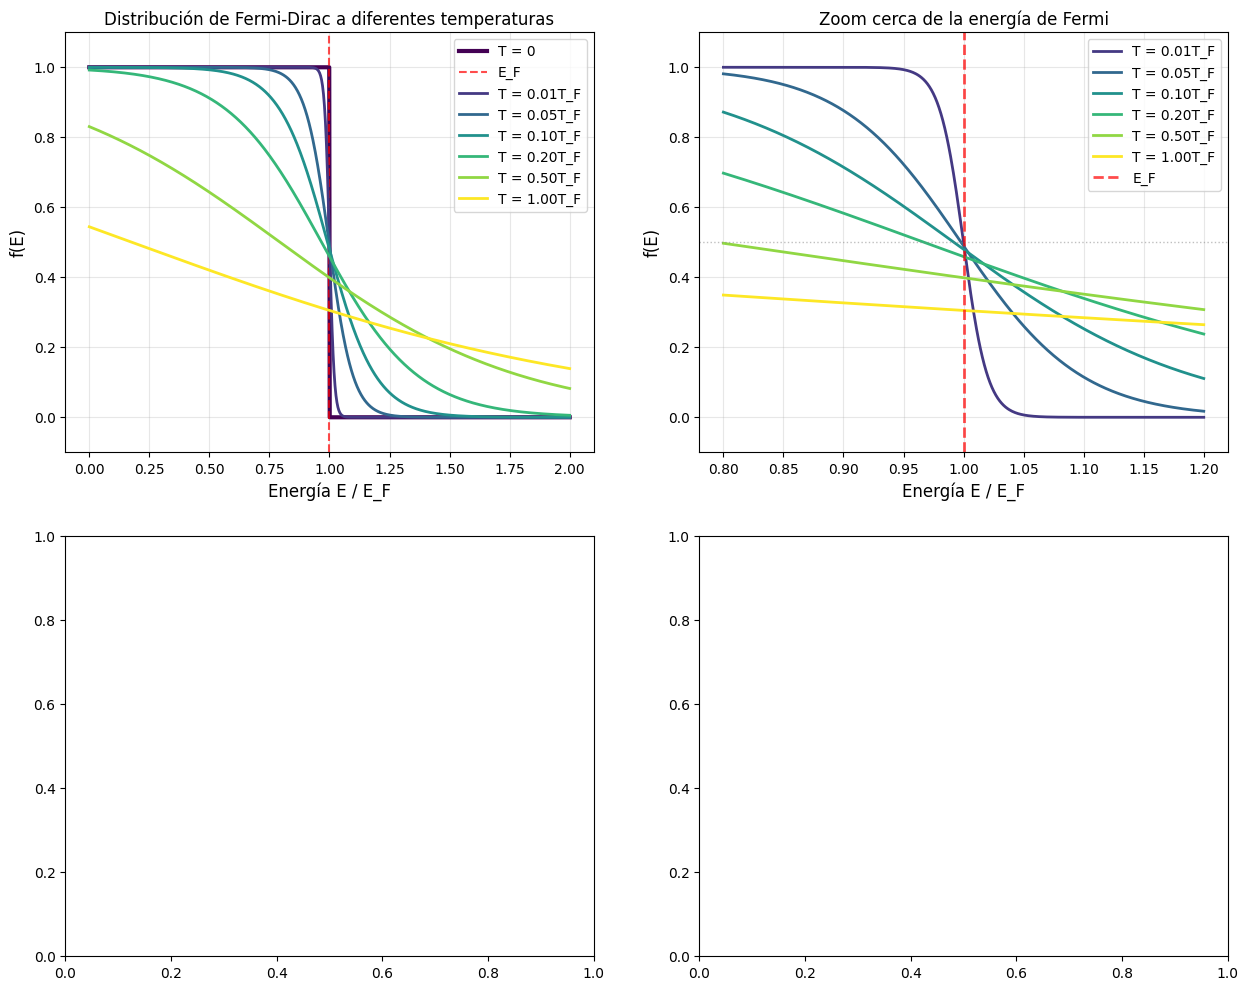

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Configuración de estilo
plt.style.use('default')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12

def fermi_dirac_distribution(energy, mu, T, kB=1):
    """
    Distribución de Fermi-Dirac
    """
    if T == 0:
        # Caso T=0: función escalón
        return np.where(energy <= mu, 1, 0)
    else:
        exponent = (energy - mu) / (kB * T)
        # Para evitar overflow numérico
        with np.errstate(over='ignore'):
            distribution = 1.0 / (np.exp(exponent) + 1)
        return distribution

def chemical_potential_approx(T, EF, kB=1):
    """
    Aproximación del potencial químico a bajas temperaturas
    μ ≈ EF [1 - (π²/12)(kT/EF)² + ...]
    """
    if T == 0:
        return EF
    else:
        return EF * (1 - (np.pi**2 / 12) * (kB * T / EF)**2)

# =============================================
# PARÁMETROS DEL SISTEMA
# =============================================
EF = 1.0      # Energía de Fermi
kB = 1.0
T_F = EF / kB  # Temperatura de Fermi

# Temperaturas a graficar (en unidades de T_F)
temperaturas = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
colores = plt.cm.viridis(np.linspace(0, 1, len(temperaturas)))

# =============================================
# GRÁFICO 1: Distribución de Fermi-Dirac
# =============================================
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Rango de energías
energy = np.linspace(0, 2, 1000)

for i, T_frac in enumerate(temperaturas):
    T = T_frac * T_F
    
    if T == 0:
        mu = EF
        distribution = fermi_dirac_distribution(energy, mu, T, kB)
        label = 'T = 0'
        linewidth = 3
        linestyle = '-'
    else:
        mu = chemical_potential_approx(T, EF, kB)
        distribution = fermi_dirac_distribution(energy, mu, T, kB)
        label = f'T = {T_frac:.2f}T_F'
        linewidth = 2
        linestyle = '-'
    
    ax1.plot(energy, distribution, color=colores[i], 
             linewidth=linewidth, linestyle=linestyle, label=label)
    
    # Marcar la energía de Fermi
    if T_frac == 0:
        ax1.axvline(x=EF, color='red', linestyle='--', alpha=0.7, label='E_F')

ax1.set_xlabel('Energía E / E_F')
ax1.set_ylabel('f(E)')
ax1.set_title('Distribución de Fermi-Dirac a diferentes temperaturas')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.1, 1.1)

# =============================================
# GRÁFICO 2: Zoom cerca de E_F
# =============================================
energy_zoom = np.linspace(EF - 0.2, EF + 0.2, 500)

for i, T_frac in enumerate(temperaturas):
    T = T_frac * T_F
    
    if T == 0:
        continue  # Saltar T=0 para el zoom
    
    mu = chemical_potential_approx(T, EF, kB)
    distribution = fermi_dirac_distribution(energy_zoom, mu, T, kB)
    
    ax2.plot(energy_zoom, distribution, color=colores[i], 
             linewidth=2, label=f'T = {T_frac:.2f}T_F')

# Línea vertical en E_F
ax2.axvline(x=EF, color='red', linestyle='--', alpha=0.7, linewidth=2, label='E_F')
ax2.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)

ax2.set_xlabel('Energía E / E_F')
ax2.set_ylabel('f(E)')
ax2.set_title('Zoom cerca de la energía de Fermi')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.1, 1.1)

# =============================================
# GRÁFICO 3: Potencial químico vs Temperatura
# =============================================
T_range = np.linspace(0, 2.0, 200) * T_F
mu_values = [chemical_potential_approx(T, EF, kB) if T > 0 else EF for T in T_range]

ax3.plot(T_range/T_F, mu_values/EF, 'b-', linewidth=3)
ax3.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='E_F')
ax3.axvline(x=0, color='gray', linestyle=':', alpha=0.5)

ax3.set_xlabel('T / T_F')
ax3.set_ylabel('μ / E_F')
ax3.set_title('Potencial Químico vs Temperatura\n(Expansión a bajas T: μ ≈ E_F[1 - (π²/12)(T/T_F)²])')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0.8, 1.02)

# =============================================
# GRÁFICO 4: Derivada -df/dE y anchura térmica
# =============================================
energy_deriv = np.linspace(EF - 0.3, EF + 0.3, 500)

T_low = [0.01, 0.05, 0.1, 0.2]  # Bajas temperaturas
colors_deriv = plt.cm.plasma(np.linspace(0, 1, len(T_low)))

for i, T_frac in enumerate(T_low):
    T = T_frac * T_F
    mu = chemical_potential_approx(T, EF, kB)
    
    # Calcular derivada numéricamente
    distribution = fermi_dirac_distribution(energy_deriv, mu, T, kB)
    derivative = -np.gradient(distribution, energy_deriv)
    
    ax4.plot(energy_deriv, derivative, color=colors_deriv[i], 
             linewidth=2, label=f'T = {T_frac:.2f}T_F')

ax4.axvline(x=EF, color='red', linestyle='--', alpha=0.7, label='E_F')
ax4.set_xlabel('Energía E / E_F')
ax4.set_ylabel('-df/dE')
ax4.set_title('Derivada de la distribución de Fermi\n(Anchura térmica ~ kT)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# GRÁFICO 5: Propiedades termodinámicas a bajas T
# =============================================
fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 5))

# Calor específico electrónico (∝ T)
T_range_cv = np.linspace(0.01, 1.0, 100) * T_F
cv_electron = (np.pi**2 / 2) * (T_range_cv / T_F)  # En unidades de N*kB

ax5.plot(T_range_cv/T_F, cv_electron, 'r-', linewidth=3)
ax5.set_xlabel('T / T_F')
ax5.set_ylabel('C_V / (Nk_B)')
ax5.set_title('Calor Específico Electrónico\nC_V ≈ (π²/2) Nk_B (T/T_F)')
ax5.grid(True, alpha=0.3)

# Susceptibilidad de Pauli (∝ constante)
chi_pauli = np.ones_like(T_range_cv)  # Aproximación a bajas T

ax6.plot(T_range_cv/T_F, chi_pauli, 'g-', linewidth=3)
ax6.set_xlabel('T / T_F')
ax6.set_ylabel('χ / χ₀')
ax6.set_title('Susceptibilidad de Pauli\n(Constante a bajas T)')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# GRÁFICO 6: Comparación T=0 vs T baja
# =============================================
fig3, ax7 = plt.subplots(1, 1, figsize=(10, 6))

# Distribución a T=0 (escalón perfecto)
distribution_T0 = fermi_dirac_distribution(energy, EF, 0, kB)
ax7.plot(energy, distribution_T0, 'k-', linewidth=3, label='T = 0', alpha=0.8)

# Distribución a T baja
T_low_example = 0.1 * T_F
mu_low = chemical_potential_approx(T_low_example, EF, kB)
distribution_Tlow = fermi_dirac_distribution(energy, mu_low, T_low_example, kB)
ax7.plot(energy, distribution_Tlow, 'r--', linewidth=2, 
         label=f'T = {0.1:.1f}T_F', alpha=0.8)

# Rellenar áreas
ax7.fill_between(energy, 0, distribution_T0, alpha=0.2, color='blue', label='Estados ocupados (T=0)')
ax7.fill_between(energy[energy > EF], 0, distribution_Tlow[energy > EF], 
                alpha=0.2, color='red', label='Excitaciones térmicas')

ax7.axvline(x=EF, color='red', linestyle='--', alpha=0.7, linewidth=2, label='E_F')
ax7.set_xlabel('Energía E / E_F')
ax7.set_ylabel('f(E)')
ax7.set_title('Comparación: T=0 vs T baja\n(Excitaciones térmicas cerca de E_F)')
ax7.legend()
ax7.grid(True, alpha=0.3)
ax7.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

# =============================================
# INFORMACIÓN NUMÉRICA
# =============================================
print("="*60)
print("PROPIEDADES DE FERMI-DIRAC A BAJAS TEMPERATURAS")
print("="*60)
print(f"Energía de Fermi: E_F = {EF}")
print(f"Temperatura de Fermi: T_F = E_F/k_B = {T_F:.3f}")
print("\nComportamientos importantes a bajas T (T << T_F):")
print("1. Distribución: f(E) ≈ escalón en E_F con bordes suavizados ~ kT")
print("2. Potencial químico: μ ≈ E_F [1 - (π²/12)(T/T_F)²]")
print("3. Calor específico: C_V ≈ (π²/2) Nk_B (T/T_F)")
print("4. Susceptibilidad de Pauli: χ ≈ constante")
print("5. Anchura térmica de la transición: ΔE ~ 4kT")

print("\nEjemplos numéricos:")
for T_frac in [0.0, 0.01, 0.05, 0.1, 0.2]:
    T_val = T_frac * T_F
    if T_val == 0:
        mu_val = EF
        width = 0
    else:
        mu_val = chemical_potential_approx(T_val, EF, kB)
        width = 4 * kB * T_val  # Anchura aproximada de la transición
    
    print(f"T/T_F = {T_frac:.2f}: μ/E_F = {mu_val/EF:.4f}, Anchura ~ {width/EF:.4f} E_F")

In [8]:
##CARGA DE DATOS## 
def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                
                continue

    return np.array(columnas)

In [13]:
##GRAFICA Y AJUSTE##
def plot_ajuste(x, z, y,err_z, err_y, err_x, tittle, x_tittle, y_tittle,z_ajuste, 
                x_ajuste, y_ajuste, residuales_norm1, residuales_norm2, z_legend = "D2", y_legend = "D1",
                color_n1="#D6259B", color_n2="#51D63F"):

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 14), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )
    
    # --- Gráfico principal ---
    ax1.set_title(tittle, fontsize=22, weight="bold")
    ax1.set_ylabel(x_tittle, fontsize=20)
    ax1.tick_params(axis="both", labelsize=20, width=2)  # ticks más grandes y gruesos
    ax1.grid(True, alpha=0.3)

    # Ejes más gruesos
    for spine in ax1.spines.values():
        spine.set_linewidth(2)

    ax1.errorbar(
        x, y, xerr=err_x, yerr=err_y,
        fmt="v", markersize=10, mfc=color_n1, mec="black",
        elinewidth=2, capthick=2, color=color_n1,
        label= y_legend + " con error"
    )
    ax1.errorbar(
        x, z, xerr=err_x, yerr=err_z,
        fmt="o", markersize=10, mfc=color_n2, mec="black",
        elinewidth=2, capthick=2, color=color_n2,
        label= z_legend + " con error"
    )   

    ax1.plot(x_ajuste, y_ajuste, "--", linewidth=3,
             color="black", label="Línea de ajuste")
    ax1.plot(x_ajuste, z_ajuste, "--", linewidth=3,
             color="gray", label="Línea de ajuste")
    ax1.legend(fontsize=16)

    # --- Gráfico de residuales ---
    ax2.set_xlabel(y_tittle, fontsize=20)
    ax2.set_ylabel("Residuales\n(normalizados)", fontsize=20)
    ax2.tick_params(axis="both", labelsize=20, width=2)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=2)

    for spine in ax2.spines.values():
        spine.set_linewidth(2)

    ax2.scatter(x, residuales_norm1, color=color_n2, s=90, edgecolor="black")
    ax2.scatter(x, residuales_norm2, color=color_n1, s=90, edgecolor="black")
    ax2.grid(True, alpha=0.3)
    ax1.set_xlim(0, max(x) + 0.01)
    plt.tight_layout()
    plt.show()


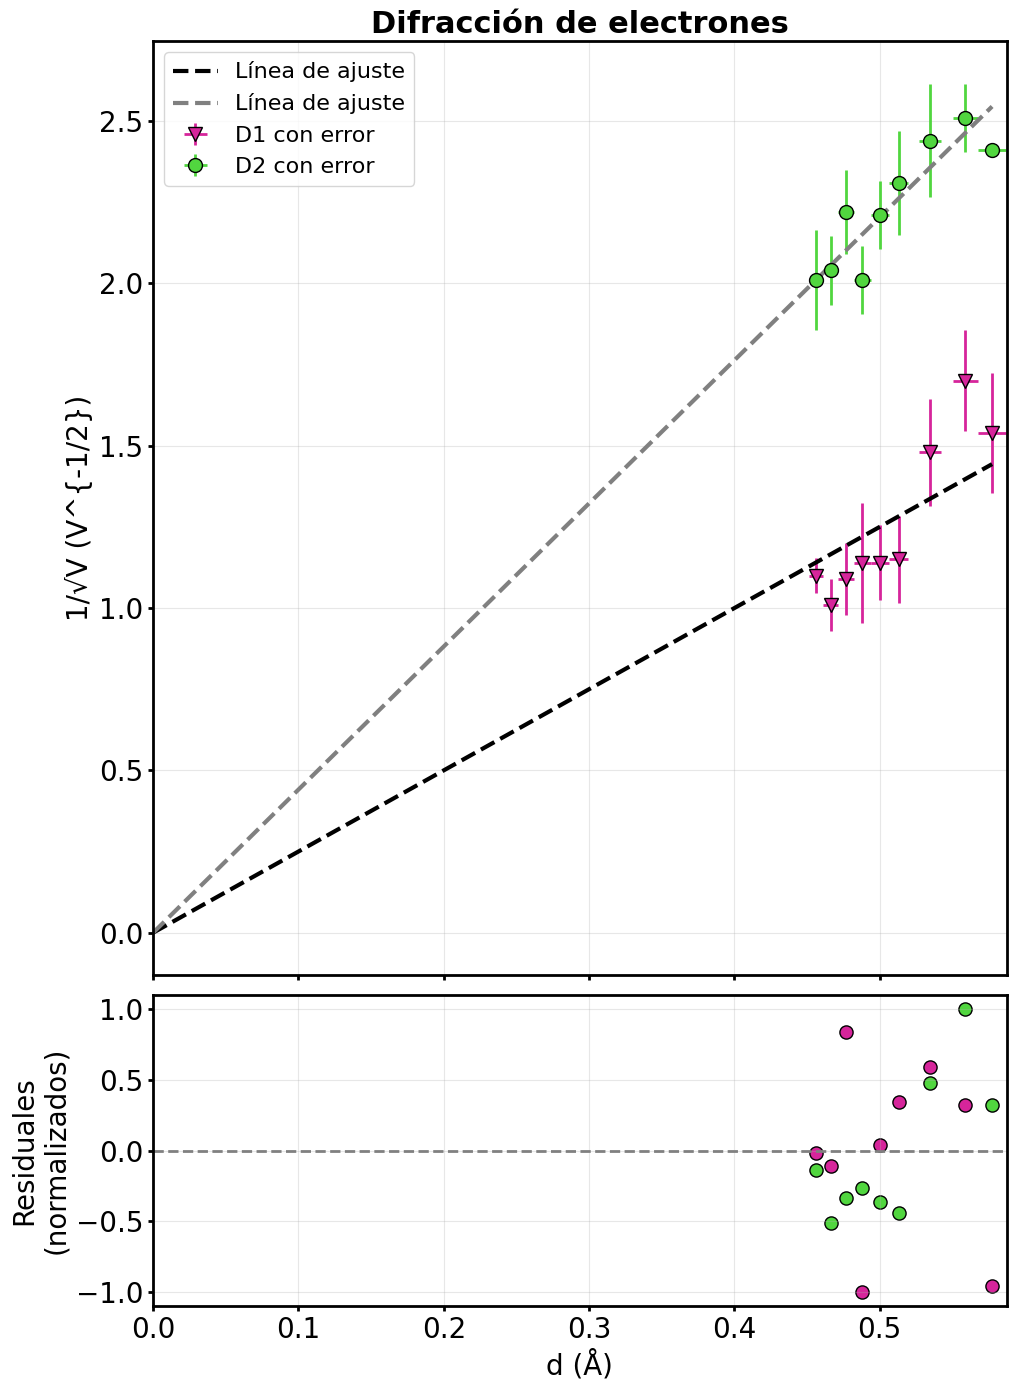

In [14]:
# --- CARGA Y PREPARACIÓN ---
archivo = "toma_de_Datos.txt"
archivo2 = "toma_de_datos_2.txt"
data = leer_columnas(archivo)
data2 = leer_columnas(archivo2)

x = 1 / (data[0]**(1/2))
err_x = 1 / (data[0]**(3/2)) * data[1] / 2
y = data2[2][:9]
err_y = (data2[3]/2)[:9]
z = data[4]
err_z = data[5]

# --- AJUSTE LINEAL FORZADO A ORIGEN (y vs x) ---
A = x.reshape(-1, 1)  # diseño sin columna de 1's -> ajuste sin intercepto
coef_y, *_ = np.linalg.lstsq(A, y, rcond=None)
mfit_y = float(coef_y[0])
bfit_y = 0.0

# incertidumbre de la pendiente (covarianza simplificada)
N = x.size
p = 1
y_pred = mfit_y * x
SSE_y = np.sum((y - y_pred)**2)
sigma2_y = SSE_y / (N - p) if N - p > 0 else 0.0
var_m_y = sigma2_y / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_y = np.sqrt(var_m_y)
sbfit_y = 0.0

# Extender la línea de ajuste hasta x=0 para que toque (0,0)
x_ajuste = np.linspace(0, x.max(), 200)
y_ajuste = mfit_y * x_ajuste  # pasa por el origen

# residuales normalizados (y)
resid_y = y - (mfit_y * x + bfit_y)
max_abs_res_y = np.max(np.abs(resid_y))
if max_abs_res_y == 0:
    residuales_norm1 = np.zeros_like(resid_y)
    err_res_norm1 = np.zeros_like(err_y)
else:
    residuales_norm1 = resid_y / max_abs_res_y
    err_res_norm1 = err_y / max_abs_res_y

# --- AJUSTE LINEAL FORZADO A ORIGEN (z vs x) ---
coef_z, *_ = np.linalg.lstsq(A, z, rcond=None)
mfit_z = float(coef_z[0])
bfit_z = 0.0

z_pred = mfit_z * x
SSE_z = np.sum((z - z_pred)**2)
sigma2_z = SSE_z / (N - p) if N - p > 0 else 0.0
var_m_z = sigma2_z / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_z = np.sqrt(var_m_z)
sbfit_z = 0.0

# extender también la línea de ajuste de z hasta x=0
z_ajuste = mfit_z * x_ajuste  # pasa por el origen

# residuales normalizados (z)
resid_z = z - (mfit_z * x + bfit_z)
max_abs_res_z = np.max(np.abs(resid_z))
if max_abs_res_z == 0:
    residuales_norm2 = np.zeros_like(resid_z)
    err_res_norm2 = np.zeros_like(err_z)
else:
    residuales_norm2 = resid_z / max_abs_res_z
    err_res_norm2 = err_z / max_abs_res_z

# --- PLOT ---
plot_ajuste(
    x, z, y, err_z, err_y, err_x,
    tittle="Difracción de electrones",
    x_tittle="1/√V (V^{-1/2})",
    y_tittle="d (Å)",
    z_ajuste=z_ajuste,
    x_ajuste=x_ajuste,
    y_ajuste=y_ajuste,
    residuales_norm1=residuales_norm1,
    residuales_norm2=residuales_norm2
)

In [16]:
from tabulate import tabulate
from scipy.constants import h, m_e, e
import numpy as np

# === Lectura de datos ===
V = leer_columnas(archivo)[0]  # Voltaje en kV
error_V = 0.1  # error instrumental en kV

# === Conversión a voltios ===
V_volt = V * 1e3
error_V_volt = error_V * 1e3

# === Cálculo de λ de Broglie en picómetros ===
lambda_broglie = (h / np.sqrt(2 * m_e * e * V_volt)) * 1e12  # [pm]
lambda_error = (h / (2 * np.sqrt(2 * m_e * e))) * (error_V_volt / (V_volt ** (3/2))) * 1e12  # [pm]

# === Datos de diámetros ===
pie_rey = 0.025  # cm
D1, bordes1 = leer_columnas(archivo)[2], leer_columnas(archivo)[3]
D2, bordes2 = leer_columnas(archivo)[4], leer_columnas(archivo)[5]

error_1 = np.sqrt(pie_rey**2 + bordes1**2)
error_2 = np.sqrt(pie_rey**2 + bordes2**2)

# === Cálculo de λ de Bragg en picómetros ===
L= 13.5 #Cm
D= D1 
n = 1 
lambda_bragg = D1*D2 / 2*L
lambda_bragg_error = np.sqrt((D2 * error_1/2*n*L)**(1/2) + (D1 * error_2/2*n*L)**(1/2) )

sigma_comb = np.sqrt(lambda_bragg_error**2 + lambda_error**2)  # pm
# Evitar división por cero:
sigma_comb = np.where(sigma_comb == 0, np.nan, sigma_comb)
z_sigma = (lambda_bragg - lambda_broglie) / sigma_comb
z_abs = np.abs(z_sigma)


### PRECISION 
avg_precision_D1 = (lambda_bragg_error/ lambda_bragg)*100
avg_precision_D2 = (lambda_error / lambda_broglie)*100

# (Opcional) Etiqueta simple según umbrales
def etiqueta_sigmas(z):
    if np.isnan(z): return "—"
    if z_abs_i := abs(z) < 1:  return "<1σ"
    if z_abs_i < 2:            return "1–2σ"
    if z_abs_i < 3:            return "2–3σ"
    return "≥3σ"

labels = [etiqueta_sigmas(z) for z in z_abs]

# === Tabla ===
data = []
for i in range(len(V)):
    data.append([
        V[i], D1[i], error_1[i],
        D2[i], error_2[i],
        lambda_broglie[i], lambda_error[i],
        lambda_bragg[i],  lambda_bragg_error[i],
        z_sigma[i], z_abs[i], labels[i], avg_precision_D1[i], avg_precision_D2[i]
    ])

print(tabulate(
    data,
    headers=[
        "V (kV)", "d (cm)", "σ_d (cm)", "D (cm)", "σ_D (cm)",
        "λ_deB (pm)", "σ_λ_deB (pm)", "λ_Bragg (pm)", "σ_λ_B (pm)",
        "z (σ)", "|z|", "Etiqueta"," Precisión %", "Precisión %"
    ],
    floatfmt=(".2f")
))


ModuleNotFoundError: No module named 'tabulate'

## Tercera toma datos


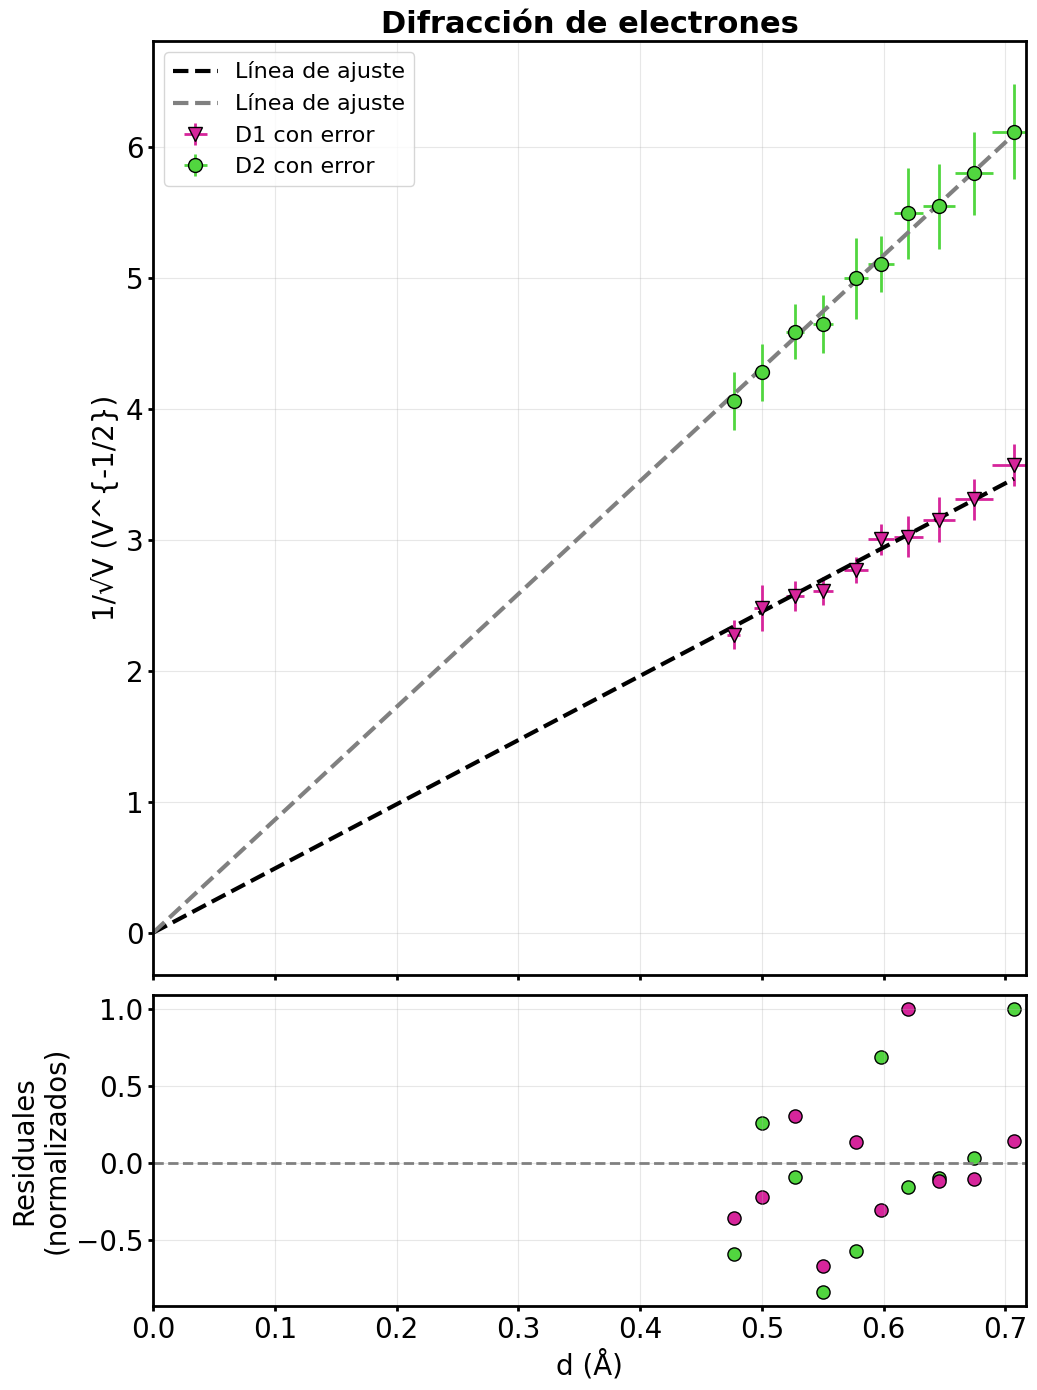

In [17]:
# --- CARGA Y PREPARACIÓN ---
archivo2 = "toma_de_datos_3.txt"
data2 = leer_columnas(archivo2)

# Variables desde el archivo 2
x = 1 / np.sqrt(data2[0])              # 1 / √V
err_x = data2[1] / (2 * data2[0]**(3/2))  # propagación de error

y = data2[2]                           # columna d (Å)
err_y = data2[3] / 2                   # error asociado a d

z = data2[4]                           # si hay una segunda serie de datos (por ejemplo, otro anillo)
err_z = data2[5]

# --- AJUSTE LINEAL FORZADO A ORIGEN (y vs x) ---
A = x.reshape(-1, 1)  # diseño sin intercepto
coef_y, *_ = np.linalg.lstsq(A, y, rcond=None)
mfit_y = float(coef_y[0])
bfit_y = 0.0

# incertidumbre de la pendiente (covarianza simplificada)
N = x.size
p = 1
y_pred = mfit_y * x
SSE_y = np.sum((y - y_pred)**2)
sigma2_y = SSE_y / (N - p) if N - p > 0 else 0.0
var_m_y = sigma2_y / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_y = np.sqrt(var_m_y)
sbfit_y = 0.0

# Extender línea de ajuste hasta x=0
x_ajuste = np.linspace(0, x.max(), 200)
y_ajuste = mfit_y * x_ajuste  # pasa por el origen

# residuales normalizados (y)
resid_y = y - (mfit_y * x + bfit_y)
max_abs_res_y = np.max(np.abs(resid_y))
if max_abs_res_y == 0:
    residuales_norm1 = np.zeros_like(resid_y)
    err_res_norm1 = np.zeros_like(err_y)
else:
    residuales_norm1 = resid_y / max_abs_res_y
    err_res_norm1 = err_y / max_abs_res_y

# --- AJUSTE LINEAL FORZADO A ORIGEN (z vs x) ---
coef_z, *_ = np.linalg.lstsq(A, z, rcond=None)
mfit_z = float(coef_z[0])
bfit_z = 0.0

z_pred = mfit_z * x
SSE_z = np.sum((z - z_pred)**2)
sigma2_z = SSE_z / (N - p) if N - p > 0 else 0.0
var_m_z = sigma2_z / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_z = np.sqrt(var_m_z)
sbfit_z = 0.0

# extender línea de ajuste de z
z_ajuste = mfit_z * x_ajuste  # pasa por el origen

# residuales normalizados (z)
resid_z = z - (mfit_z * x + bfit_z)
max_abs_res_z = np.max(np.abs(resid_z))
if max_abs_res_z == 0:
    residuales_norm2 = np.zeros_like(resid_z)
    err_res_norm2 = np.zeros_like(err_z)
else:
    residuales_norm2 = resid_z / max_abs_res_z
    err_res_norm2 = err_z / max_abs_res_z

# --- PLOT ---
plot_ajuste(
    x, z, y, err_z, err_y, err_x,
    tittle="Difracción de electrones",
    x_tittle="1/√V (V^{-1/2})",
    y_tittle="d (Å)",
    z_ajuste=z_ajuste,
    x_ajuste=x_ajuste,
    y_ajuste=y_ajuste,
    residuales_norm1=residuales_norm1,
    residuales_norm2=residuales_norm2
)


In [18]:
from tabulate import tabulate
from scipy.constants import h, m_e, e
import numpy as np
archivo = archivo2
# === Lectura de datos ===
V = leer_columnas(archivo)[0]  # Voltaje en kV
error_V = 0.1  # error instrumental en kV

# === Conversión a voltios ===
V_volt = V * 1e3
error_V_volt = error_V * 1e3

# === Cálculo de λ de Broglie en picómetros ===
lambda_broglie = (h / np.sqrt(2 * m_e * e * V_volt)) * 1e12  # [pm]
lambda_error = (h / (2 * np.sqrt(2 * m_e * e))) * (error_V_volt / (V_volt ** (3/2))) * 1e12  # [pm]

# === Datos de diámetros ===
pie_rey = 0.025  # cm
D1, bordes1 = leer_columnas(archivo)[2], leer_columnas(archivo)[3]
D2, bordes2 = leer_columnas(archivo)[4], leer_columnas(archivo)[5]

error_1 = np.sqrt(pie_rey**2 + bordes1**2)
error_2 = np.sqrt(pie_rey**2 + bordes2**2)

# === Cálculo de λ de Bragg en picómetros ===
L= 13.5 #Cm
D= D1 
n = 1 
lambda_bragg = D1*D2 / 2*L
lambda_bragg_error = np.sqrt((D2 * error_1/2*n*L)**(1/2) + (D1 * error_2/2*n*L)**(1/2) )

sigma_comb = np.sqrt(lambda_bragg_error**2 + lambda_error**2)  # pm
# Evitar división por cero:
sigma_comb = np.where(sigma_comb == 0, np.nan, sigma_comb)
z_sigma = (lambda_bragg - lambda_broglie) / sigma_comb
z_abs = np.abs(z_sigma)


### PRECISION 
avg_precision_D1 = (lambda_bragg_error/ lambda_bragg)*100
avg_precision_D2 = (lambda_error / lambda_broglie)*100

# (Opcional) Etiqueta simple según umbrales
def etiqueta_sigmas(z):
    if np.isnan(z): return "—"
    if z_abs_i := abs(z) < 1:  return "<1σ"
    if z_abs_i < 2:            return "1–2σ"
    if z_abs_i < 3:            return "2–3σ"
    return "≥3σ"

labels = [etiqueta_sigmas(z) for z in z_abs]

# === Tabla ===
data = []
for i in range(len(V)):
    data.append([
        V[i], D1[i], error_1[i],
        D2[i], error_2[i],
        lambda_broglie[i], lambda_error[i],
        lambda_bragg[i],  lambda_bragg_error[i],
        z_sigma[i], z_abs[i], labels[i], avg_precision_D1[i], avg_precision_D2[i]
    ])

print(tabulate(
    data,
    headers=[
        "V (kV)", "d (cm)", "σ_d (cm)", "D (cm)", "σ_D (cm)",
        "λ_deB (pm)", "σ_λ_deB (pm)", "λ_Bragg (pm)", "σ_λ_B (pm)",
        "z (σ)", "|z|", "Etiqueta"," Precisión %", "Precisión %"
    ],
    floatfmt=(".2f")
))


ModuleNotFoundError: No module named 'tabulate'

In [20]:
from tabulate import tabulate
from scipy.constants import h, m_e, e
import numpy as np

# === Lectura de datos ===
archivo = archivo2
V = leer_columnas(archivo)[0]  # Voltaje en kV
error_V = 0.1  # error instrumental en kV

# === Conversión a voltios ===
V_volt = V * 1e3
error_V_volt = error_V * 1e3

# === Datos de diámetros ===
pie_rey = 0.025  # cm
D1, sD1 = leer_columnas(archivo)[2], leer_columnas(archivo)[3]
D2, sD2 = leer_columnas(archivo)[4], leer_columnas(archivo)[5]

# === Parámetros ===
L = 13.5  # cm
n = 1
# Distancias interplanares del grafito
d1 = 0.213e-9  # [m]
d2 = 0.123e-9  # [m]

# === λ de De Broglie ===
lambda_broglie = (h / np.sqrt(2 * m_e * e * V_volt)) * 1e12  # [pm]
lambda_error = (h / (2 * np.sqrt(2 * m_e * e))) * (error_V_volt / (V_volt ** (3/2))) * 1e12  # [pm]

# === λ de Bragg (exacta) ===
theta1 = 0.5 * np.arctan(D1 / (2 * L))
theta2 = 0.5 * np.arctan(D2 / (2 * L))
lambda_bragg1 = 2 * d1 * np.sin(theta1) * 1e12  # [pm]
lambda_bragg2 = 2 * d2 * np.sin(theta2) * 1e12  # [pm]

# === λ de Bragg (aprox. ángulo pequeño) ===
lambda_bragg1_aprox = (d1 * D1 / (2 * L)) * 1e12  # [pm]
lambda_bragg2_aprox = (d2 * D2 / (2 * L)) * 1e12  # [pm]

# === Errores propagados (solo del diámetro) ===
lambda_bragg1_err = lambda_bragg1 * (sD1 / D1)
lambda_bragg2_err = lambda_bragg2 * (sD2 / D2)

# === Tabla ===
data = []
for i in range(len(V)):
    data.append([
        V[i],
        D1[i], sD1[i],
        D2[i], sD2[i],
        lambda_broglie[i], lambda_error[i],
        lambda_bragg1[i], lambda_bragg1_aprox[i], lambda_bragg1_err[i],
        lambda_bragg2[i], lambda_bragg2_aprox[i], lambda_bragg2_err[i]
    ])

print(tabulate(
    data,
    headers=[
        "V (kV)",
        "D1 (cm)", "σ_D1", "D2 (cm)", "σ_D2",
        "λ_deB (pm)", "σ_λ_deB (pm)",
        "λ_Bragg1 (pm)", "λ_Bragg1_aprox (pm)", "σ_λB1",
        "λ_Bragg2 (pm)", "λ_Bragg2_aprox (pm)", "σ_λB2"
    ],
    floatfmt=(".2f", ".2f", ".1f", ".2f", ".1f", ".2f", ".2f", ".2f", ".1f", ".1f", ".2f", ".2f", ".1f")
))


ModuleNotFoundError: No module named 'tabulate'

In [23]:
from tabulate import tabulate
from scipy.constants import h, m_e, e
import numpy as np

# === Lectura de datos (ajusta leer_columnas según tu entorno) ===
V = leer_columnas(archivo2)[0]  # Voltaje en kV
error_V = 0.1  # error instrumental en kV

# === Conversión a voltios ===
V_volt = V * 1e3
error_V_volt = error_V * 1e3

# === λ de De Broglie (pm) ===
lambda_broglie = (h / np.sqrt(2 * m_e * e * V_volt)) * 1e12
lambda_error = (h / (2 * np.sqrt(2 * m_e * e))) * (error_V_volt / (V_volt ** (3/2))) * 1e12

# === Datos experimentales de diámetros ===
pie_rey = 0.025  # cm
D1, bordes1 = leer_columnas(archivo2)[2], leer_columnas(archivo2)[3]
D2, bordes2 = leer_columnas(archivo2)[4], leer_columnas(archivo2)[5]

error_1 = np.sqrt(pie_rey**2 + bordes1**2)
error_2 = np.sqrt(pie_rey**2 + bordes2**2)

# === Parámetros geométricos ===
L = 13.5  # cm
n = 1
d1 = 213  # pm
d2 = 123  # pm (actualizado según tu solicitud)

# === λ de Bragg (pm) ===
lambda_bragg_D1 = (D1 * d1) / (2 * L * n) 
lambda_bragg_error_D1 = (d1 * error_1 / (2 * L * n)) 

lambda_bragg_D2 = (D2 * d2) / (2 * L * n) 
lambda_bragg_error_D2 = (d2 * error_2 / (2 * L * n)) 

# === Desviación estándar combinada ===
sigma_comb_D1 = np.sqrt(lambda_bragg_error_D1**2 + lambda_error**2)
sigma_comb_D2 = np.sqrt(lambda_bragg_error_D2**2 + lambda_error**2)

# === Precisión (incertidumbre relativa en %) ===
precision_D1 = (lambda_bragg_error_D1 / lambda_bragg_D1) * 100
precision_D2 = (lambda_bragg_error_D2 / lambda_bragg_D2) * 100

# === Exactitud en términos de σ combinada (z-score) ===
exactitud_sigma_D1 = (lambda_bragg_D1 - lambda_broglie) / sigma_comb_D1
exactitud_sigma_D2 = (lambda_bragg_D2 - lambda_broglie) / sigma_comb_D2

# === Tabla combinada D1 y D2 en una sola fila por voltaje ===
data = []
for i in range(len(V)):
    data.append([
        f"{V[i]:.1f}",
        f'{D1[i]:.1f}  ± {error_1[i]:.1f}',
        f'{D2[i]:.1f}  ± {error_2[i]:.1f}',
        f"{lambda_broglie[i]:.1f} ± {lambda_error[i]:.1f}",
        f"{lambda_bragg_D1[i]:.1f} ± {lambda_bragg_error_D1[i]:.1f}",
        f"{lambda_bragg_D2[i]:.1f} ± {lambda_bragg_error_D2[i]:.1f}",
        f"{sigma_comb_D1[i]:.1f}",
        f"{sigma_comb_D2[i]:.1f}",
        f"{precision_D1[i]:.1f}",
        f"{precision_D2[i]:.1f}",
        f"{exactitud_sigma_D1[i]:.1f}",
        f"{exactitud_sigma_D2[i]:.1f}"
    ])

# === Impresión con formato elegante ===
print(tabulate(
    data,
    headers=[
        "V (kV)", "D1" , "D2",
        "λ_De Broglie ± σ (pm)",
        "λ_Bragg D1 ± σ (pm)",
        "λ_Bragg D2 ± σ (pm)",
        "σ_comb D1 (pm)",
        "σ_comb D2 (pm)",
        "Prec. D1 (%)",
        "Prec. D2 (%)",
        "Exact. D1 (σ)",
        "Exact. D2 (σ)"
    ],
    stralign="center",
    numalign="right",
    tablefmt="grid"
))

ModuleNotFoundError: No module named 'tabulate'

In [27]:
import numpy as np
from scipy.constants import m_e, e

# Asumiendo que ya tienes los arrays h1, h2, σ_h1, σ_h2 calculados
# Voy a simular los cálculos basados en tu código

# === Cálculo de desviación estándar ===
std_h1 = np.std(h1, ddof=1)  # Desviación estándar muestral
std_h2 = np.std(h2, ddof=1)

# === Exactitud (comparación con valor teórico) ===
h_tab = 6.62607015e-34  # Valor teórico

# Exactitud en términos de desviaciones estándar
exactitud_std_h1 = abs(h_prom1 - h_tab) / std_h1
exactitud_std_h2 = abs(h_prom2 - h_tab) / std_h2

# Exactitud porcentual
exactitud_porcentual_h1 = abs((h_prom1 - h_tab) / h_tab) * 100
exactitud_porcentual_h2 = abs((h_prom2 - h_tab) / h_tab) * 100

# === Precisión para el promedio ===
# Error estándar de la media (precisión del promedio)
precision_promedio_h1 = std_h1 / np.sqrt(len(h1))
precision_promedio_h2 = std_h2 / np.sqrt(len(h2))

# Precisión relativa del promedio (%)
precision_relativa_h1 = (precision_promedio_h1 / h_prom1) * 100
precision_relativa_h2 = (precision_promedio_h2 / h_prom2) * 100

# === Mostrar resultados ===
print("=" * 60)
print("ANÁLISIS ESTADÍSTICO DE LA CONSTANTE DE PLANCK")
print("=" * 60)

print(f"\n--- PARA h₁ (d1 = 213 pm) ---")
print(f"Promedio: {h_prom1:.4e} J·s")
print(f"Desviación estándar: {std_h1:.4e} J·s")
print(f"Exactitud (diferencia con teórico): {abs(h_prom1 - h_tab):.4e} J·s")
print(f"Exactitud en términos de σ: {exactitud_std_h1:.2f} σ")
print(f"Exactitud porcentual: {exactitud_porcentual_h1:.2f}%")
print(f"Precisión del promedio (error estándar): {precision_promedio_h1:.4e} J·s")
print(f"Precisión relativa del promedio: {precision_relativa_h1:.2f}%")

print(f"\n--- PARA h₂ (d2 = 123 pm) ---")
print(f"Promedio: {h_prom2:.4e} J·s")
print(f"Desviación estándar: {std_h2:.4e} J·s")
print(f"Exactitud (diferencia con teórico): {abs(h_prom2 - h_tab):.4e} J·s")
print(f"Exactitud en términos de σ: {exactitud_std_h2:.2f} σ")
print(f"Exactitud porcentual: {exactitud_porcentual_h2:.2f}%")
print(f"Precisión del promedio (error estándar): {precision_promedio_h2:.4e} J·s")
print(f"Precisión relativa del promedio: {precision_relativa_h2:.2f}%")

print(f"\n--- COMPARACIÓN CON VALOR TEÓRICO ---")
print(f"Valor teórico: {h_tab:.4e} J·s")

print(f"\n--- RESUMEN DE INCERTIDUMBRES ---")
print(f"h₁: ({h_prom1:.4e} ± {precision_promedio_h1:.4e}) J·s")
print(f"h₂: ({h_prom2:.4e} ± {precision_promedio_h2:.4e}) J·s")

# === Interpretación ===
print(f"\n--- INTERPRETACIÓN ---")
print("Exactitud en términos de σ:")
print("• < 1σ: Excelente acuerdo con valor teórico")
print("• 1-2σ: Buen acuerdo")
print("• 2-3σ: Acuerdo moderado") 
print("• > 3σ: Desviación significativa")

print(f"\nPrecisión del promedio:")
print("• Error estándar < 1%: Muy precisa")
print("• Error estándar 1-5%: Precisa")
print("• Error estándar > 5%: Poca precisión")

ANÁLISIS ESTADÍSTICO DE LA CONSTANTE DE PLANCK

--- PARA h₁ (d1 = 213 pm) ---
Promedio: 6.5930e-34 J·s
Desviación estándar: 1.3962e-35 J·s
Exactitud (diferencia con teórico): 3.3106e-36 J·s
Exactitud en términos de σ: 0.24 σ
Exactitud porcentual: 0.50%
Precisión del promedio (error estándar): 4.4152e-36 J·s
Precisión relativa del promedio: 0.67%

--- PARA h₂ (d2 = 123 pm) ---
Promedio: 6.7059e-34 J·s
Desviación estándar: 8.9196e-36 J·s
Exactitud (diferencia con teórico): 7.9865e-36 J·s
Exactitud en términos de σ: 0.90 σ
Exactitud porcentual: 1.21%
Precisión del promedio (error estándar): 2.8206e-36 J·s
Precisión relativa del promedio: 0.42%

--- COMPARACIÓN CON VALOR TEÓRICO ---
Valor teórico: 6.6261e-34 J·s

--- RESUMEN DE INCERTIDUMBRES ---
h₁: (6.5930e-34 ± 4.4152e-36) J·s
h₂: (6.7059e-34 ± 2.8206e-36) J·s

--- INTERPRETACIÓN ---
Exactitud en términos de σ:
• < 1σ: Excelente acuerdo con valor teórico
• 1-2σ: Buen acuerdo
• 2-3σ: Acuerdo moderado
• > 3σ: Desviación significativa

Pre